# Proyecto: Amigrante


Mi objetivo con este proyecto, es crear una aplicacion en la que se pueda dar a entender de manera eficaz y mas simplificada las leyes de extranjeria, para poder asesorar u orientar a una persona en situacion de ilegalidad migratoria en territorio Español. Mi idea nace, ya que como migrante se lo dificil que es entender las leyes y obtener la informacion necesaria para llevar un proceso migratorio exitoso, por eso quiero poder analizar el reglamento y poder hacer algo con mis conocimientos de migracion e informaticos para poder ayudar a quienes lo necesiten.

## Pasos a seguir:

- Paso 1: Obtener la informacion necesaria
- Paso 2: Analiazar el reglamento de migracion Ley Organica 4/2000
- Paso 3: Buscar patrones en los datos
- Paso 4: Ingenieria de caracteristicas
- Paso 5: Entrenamiento de un modelo que me ayude a predecir cuantoe exito podra tener una persona en X situacion migratoria
- Paso 6: Tests de los datos de entrenamiento y validacion de los resultados
- Paso 7: Hacer un despliegue de la aplicacion para que las personas puedan probar la aplicacion 

## Imports

In [1]:
import pandas as pd
import re
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import pdfplumber
import os
import spacy
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pyarrow

## Obtencion de datos

Obtendremos nuestros datos del Boletin Oficial del Estado BOE

In [ ]:
ruta_extranjeria = r"/workspaces/Data-Science/data/raw/BOE-Ley-Organica-4-2000.pdf"

def pdf_a_dataframe_estructurado(ruta_extranjeria, fuente_nombre, categoria_general):
    texto_completo = ""
    
    # 1. Extracción de texto con tu lógica de pdfplumber
    with pdfplumber.open(ruta_extranjeria) as pdf:
        for pagina in pdf.pages:
            extraido = pagina.extract_text()
            if extraido:
                texto_completo += extraido + "\n"

    # 2. Limpieza del BOE (Tu regex actual)
    texto_completo = re.sub(r'BOLETÍN OFICIAL DEL ESTADO.*?\n', '', texto_completo)

    # 3. Segmentación por Artículos
    patron_articulos = r'(Artículo\s+\d+\.?\s+)'
    partes = re.split(patron_articulos, texto_completo)
    
    datos = []
    # Empezamos en 1 para saltar el texto previo al primer artículo
    for i in range(1, len(partes), 2):
        num_articulo = partes[i].strip()
        contenido = partes[i+1].strip()
        
        if len(contenido) > 20:  # Filtro mínimo para evitar ruido
            datos.append({
                "Referencia": num_articulo,
                "Categorias": categoria_general, # Nueva columna necesaria
                "Texto_Legal": contenido
            })
    
    return pd.DataFrame(datos)

In [24]:
df_ley = None

## Enrequeciremos nuestro dataset con NPL

In [25]:
categorias = {
    'Trabajo': ['contrato', 'empleador', 'cuenta ajena', 'cuenta propia', 'laboral'],
    'Residencia': ['permiso', 'estancia', 'renovación', 'larga duración', 'temporal'],
    'Familia': ['reagrupación', 'hijos', 'cónyuge', 'familiar', 'matrimonio'],
    'Sanciones': ['expulsión', 'multa', 'infracción', 'detención', 'salida obligatoria'],
    'Arraigo': ['arraigo social', 'arraigo laboral', 'arraigo familiar', 'formación']
}

In [26]:
def categorizar_articulo(texto):
    tags = []
    for categoria, palabras in categorias.items():
        if any(palabra in texto.lower() for palabra in palabras):
            tags.append(categoria)
    return ", ".join(tags) if tags else "General"

# Aplicamos la función al DataFrame
df_ley['Categorias'] = df_ley['Texto_Legal'].apply(categorizar_articulo)

TypeError: 'NoneType' object is not subscriptable

In [6]:
# Añadimos métricas de densidad y complejidad
df_ley['Densidad_Legal'] = df_ley['Palabras'] / df_ley['Longitud_Texto']
df_ley['Es_Critico'] = df_ley['Categorias'].str.contains('Sanciones|Arraigo').astype(int)

# Visualizamos el DataFrame enriquecido
df_enriquecido_resumen = df_ley[['Referencia', 'Categorias', 'Palabras', 'Es_Critico']].head(10)
df_enriquecido_resumen

,Referencia,Categorias,Palabras,Es_Critico
0,Artículo 1.,General,53,0
1,Artículo 2.,General,52,0
2,Artículo 2,General,52,0
3,Artículo 2,General,144,0
4,Artículo 3.,General,34,0
5,Artículo 4.,General,49,0
6,Artículo 5.,General,47,0
7,Artículo 6.,General,52,0
8,Artículo 7.,General,44,0
9,Artículo 8.,General,52,0


## Cargamos modelo NLP

In [7]:
# Cargamos el modelo de español
nlp = spacy.load("es_core_news_sm")

def limpiar_texto_legal(texto):
    # Procesamos el texto con el modelo de SpaCy
    doc = nlp(texto.lower())
    
    # Filtramos: 
    # - Solo palabras alfabéticas (quitamos números y signos de puntuación)
    # - Solo si NO son "stop words"
    # - Extraemos el "lema" (la raíz de la palabra)
    tokens_limpios = [token.lemma_ for token in doc 
                      if token.is_alpha and not token.is_stop]
    
    return " ".join(tokens_limpios)

# 1. Creamos la columna con el texto procesado para la "máquina"
df_ley['Texto_Limpio'] = df_ley['Texto_Legal'].apply(limpiar_texto_legal)

# 2. Generamos una métrica de "Riqueza Léxica" (Palabras únicas / Palabras totales)
def riqueza_lexica(texto):
    palabras = texto.split()
    if not palabras: return 0
    return len(set(palabras)) / len(palabras)

df_ley['Riqueza_Lexica'] = df_ley['Texto_Limpio'].apply(riqueza_lexica)

## Visualizamos el WordCloud

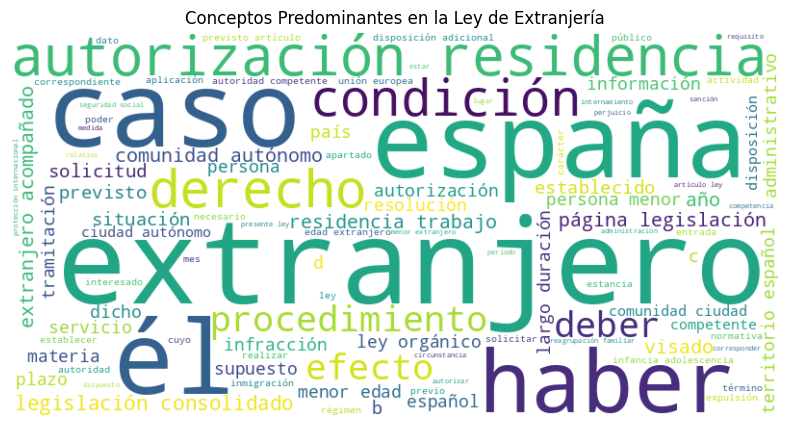

In [8]:
# Juntamos todo el texto limpio en un solo string
todo_el_texto = " ".join(df_ley['Texto_Limpio'])

# Configuramos la nube de palabras
wordcloud = WordCloud(
    width=800, 
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=100).generate(todo_el_texto)

# Mostrar el gráfico
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Conceptos Predominantes en la Ley de Extranjería")
plt.show()

## Generamos un top 10 de los articulos con más categorías críticas

In [9]:
ranking_df = df_ley.nlargest(10, 'Palabras')[['Referencia', 'Categorias', 'Palabras', 'Riqueza_Lexica']]

# Añadimos una columna de "Prioridad de Asesoría"
# Si el artículo es largo y tiene categorías críticas, le asignamos prioridad Alta
def asignar_prioridad(row):
    if row['Palabras'] > 500 or "Sanciones" in row['Categorias']:
        return "Alta (Requiere Simplificación)"
    return "Media"

ranking_df['Prioridad_App'] = ranking_df.apply(asignar_prioridad, axis=1)

ranking_df

,Referencia,Categorias,Palabras,Riqueza_Lexica,Prioridad_App
181,Artículo 72.,"Trabajo, Residencia, Familia, Sanciones, Arraigo",3637,0.370650,Alta (Requiere Simplificación)
90,Artículo 72.,"Trabajo, Arraigo",1469,0.584541,Alta (Requiere Simplificación)
159,Artículo 57.,"Trabajo, Residencia, Familia, Sanciones, Arraigo",1243,0.473137,Alta (Requiere Simplificación)
131,Artículo 35.,"Trabajo, Familia, Arraigo",1003,0.539446,Alta (Requiere Simplificación)
134,Artículo 35,General,825,0.437500,Alta (Requiere Simplificación)
183,Artículo 318,"Residencia, Sanciones, Arraigo",806,0.609467,Alta (Requiere Simplificación)
175,Artículo 66.,"Residencia, Arraigo",727,0.530120,Alta (Requiere Simplificación)
109,Artículo 17.,"Residencia, Familia",722,0.526480,Alta (Requiere Simplificación)
157,Artículo 55.,Sanciones,710,0.594771,Alta (Requiere Simplificación)
162,Artículo 59,"Residencia, Familia, Sanciones",686,0.607717,Alta (Requiere Simplificación)


## Configuramos nuestro modelo E5

In [10]:
# 1. Cargamos el nuevo modelo
# Es más pesado pero mucho más preciso para español legal
model = SentenceTransformer('intfloat/multilingual-e5-large')

# 2. IMPORTANTE: E5 requiere un prefijo para distinguir qué es una búsqueda
# Para los textos de la ley usamos: "passage: "
textos_con_prefijo = ["passage: " + str(t) for t in df_ley['Texto_Limpio'].tolist()]
embeddings_ley = model.encode(textos_con_prefijo, show_progress_bar=True, normalize_embeddings=True)

# Guardamos los nuevos vectores
df_ley['Vector'] = [v.tolist() for v in embeddings_ley]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

## Configuramos nuestras funciones de limpieza e ingesta de datos

In [11]:
def limpieza_profunda_pdf(texto):
    if not isinstance(texto, str): return ""
    texto = re.sub(r'\.{2,}', ' ', texto) # Quita puntos suspensivos
    texto = re.sub(r'[^a-zA-ZáéíóúÁÉÍÓÚñÑ0-9\s]', ' ', texto) # Quita símbolos
    texto = re.sub(r'\s+', ' ', texto) # Normaliza espacios
    return texto.strip().lower()

In [12]:
def agregar_a_base_de_datos(df_nuevo, fuente_nombre, df_principal=None):
    """
    Procesa un nuevo DataFrame legal y lo une al principal.
    Si df_principal es None, crea uno nuevo.
    """
    # 1. Limpieza y Normalización
    # Aseguramos que existan las columnas necesarias en el nuevo DF
    df_nuevo['Texto_Limpio'] = df_nuevo['Texto_Legal'].apply(limpieza_profunda_pdf)
    
    # 2. Enriquecimiento Semántico (Fuente | Categoría: Texto)
    # Esto es vital para que el modelo sepa qué ley está leyendo
    df_nuevo['Texto_Enriquecido'] = (
        f"Fuente: {fuente_nombre} | " + 
        df_nuevo['Categorias'] + ": " + 
        df_nuevo['Texto_Limpio']
    )
    
    # 3. Generación de Vectores (E5-Large con prefijo passage:)
    print(f"Vectorizando {len(df_nuevo)} artículos de: {fuente_nombre}...")
    textos_preparados = ["passage: " + t for t in df_nuevo['Texto_Enriquecido']]
    
    nuevos_embeddings = model.encode(
        textos_preparados, 
        show_progress_bar=True, 
        normalize_embeddings=True
    )
    
    df_nuevo['Vector'] = [v.tolist() for v in nuevos_embeddings]
    df_nuevo['Fuente'] = fuente_nombre
    
    # 4. Unión de datos
    if df_principal is not None:
        df_final = pd.concat([df_principal, df_nuevo], ignore_index=True)
        print(f"✅ ¡{fuente_nombre} añadido! Base de datos total: {len(df_final)} registros.")
        return df_final
    else:
        return df_nuevo

In [13]:
df_ley['Texto_Enriquecido'] = df_ley['Categorias'] + ": " + df_ley['Texto_Limpio']
textos_contextuales = ["passage: " + t for t in df_ley['Texto_Enriquecido']]
# 3. Preparamos los vectores de la Ley con el prefijo "passage: "
# Asegúrate de que df_ley tenga la columna 'Texto_Legal'
df_ley['Texto_Limpio'] = df_ley['Texto_Legal'].apply(limpieza_profunda_pdf)
textos_con_prefijo = ["passage: " + t for t in df_ley['Texto_Limpio']]

print("Generando nuevos embeddings (E5)...")
embeddings_enriquecidos = model.encode(textos_contextuales, show_progress_bar=True, normalize_embeddings=True)
df_ley['Vector'] = [v.tolist() for v in embeddings_enriquecidos]

Generando nuevos embeddings (E5)...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

In [16]:
# 4. Definimos la función de búsqueda adaptada
def buscar_asesoria_pro(pregunta_usuario, df, top_n=3, umbral=0.82): # Subimos el umbral
    pregunta_limpia = limpieza_profunda_pdf(pregunta_usuario)
    
    # Lista de términos que DEBERÍAN estar presentes para validar el dominio legal
    # Si no hay ninguno, somos más estrictos
    terminos_legales = ['ley', 'residencia', 'trabajo', 'papeles', 'permiso', 'extranjero', 'nie', 'tíe', 'documentación']
    tiene_termino_legal = any(term in pregunta_limpia for term in terminos_legales)
    
    # Si no detectamos léxico legal, subimos el umbral de exigencia al 90%
    umbral_dinamico = umbral if tiene_termino_legal else 0.90
    
    query_formateada = f"query: {pregunta_limpia}"
    vector_pregunta = model.encode([query_formateada], normalize_embeddings=True)
    matriz_vectores = np.vstack(df['Vector'].values)
    
    similitudes = cosine_similarity(vector_pregunta, matriz_vectores)
    df['Similitud'] = similitudes[0]
    
    resultados = df[df['Similitud'] >= umbral_dinamico].nlargest(top_n, 'Similitud')
    
    if resultados.empty:
        print(f"🚫 Consulta fuera de dominio o baja confianza ({df['Similitud'].max():.2f}).")
        return pd.DataFrame()
        
    return resultados[['Referencia', 'Categorias', 'Texto_Legal', 'Similitud']]


In [17]:
ruta_estatuto = r"/workspaces/Data-Science/data/raw/Estatuto de los trabajadores.pdf"
df_nuevo_estatuto = pdf_a_dataframe_estructurado(ruta_estatuto, "Estatuto de los Trabajadores", "Derecho Laboral")
df_ley = agregar_a_base_de_datos(df_nuevo_estatuto, "Estatuto de los Trabajadores", df_ley)

NameError: name 'pdf_a_dataframe_estructurado' is not defined

In [15]:
# --- TEST FINAL ---
pregunta = "Como puedo hacer pan?"
df_resultados = buscar_asesoria_pro(pregunta, df_ley)
df_resultados

🚫 Consulta fuera de dominio o baja confianza (0.79).


""


Prueba 1:

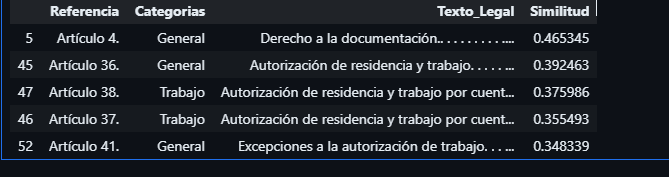

Prueba 2: 

![Captura de pantalla 2026-03-18 161347.png](<attachment:Captura de pantalla 2026-03-18 161347.png>)

Prueba 3:

![Captura de pantalla 2026-03-18 171137.png](<attachment:Captura de pantalla 2026-03-18 171137.png>)
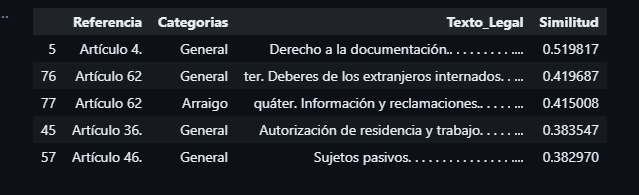
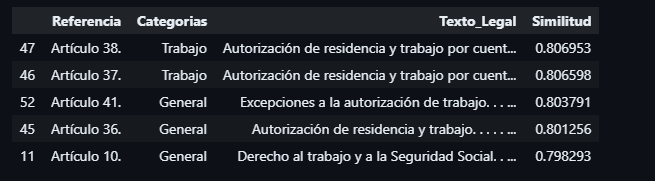

In [1]:
import re
import numpy as np
import pandas as pd
import pdfplumber
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# ==========================================
# 1. CONFIGURACIÓN Y MODELO
# ==========================================
# Cargamos el modelo robusto E5
model = SentenceTransformer('intfloat/multilingual-e5-large')

# ==========================================
# 2. FUNCIONES DE UTILIDAD
# ==========================================

def limpieza_profunda_pdf(texto):
    if not isinstance(texto, str): return ""
    # Quita puntos suspensivos y basura visual
    texto = re.sub(r'\.{2,}', ' ', texto)
    # Quita caracteres especiales manteniendo tildes y ñ
    texto = re.sub(r'[^a-zA-ZáéíóúÁÉÍÓÚñÑ0-9\s]', ' ', texto)
    # Normaliza espacios
    texto = re.sub(r'\s+', ' ', texto)
    return texto.strip().lower()

def pdf_a_dataframe_estructurado(ruta_pdf, fuente_nombre, categoria_general):
    texto_completo = ""
    with pdfplumber.open(ruta_pdf) as pdf:
        for pagina in pdf.pages:
            extraido = pagina.extract_text()
            if extraido:
                texto_completo += extraido + "\n"

    # Limpieza específica del BOE
    texto_completo = re.sub(r'BOLETÍN OFICIAL DEL ESTADO.*?\n', '', texto_completo)

    # Segmentación por "Artículo X."
    patron_articulos = r'(Artículo\s+\d+\.?\s+)'
    partes = re.split(patron_articulos, texto_completo)
    
    datos = []
    for i in range(1, len(partes), 2):
        num_articulo = partes[i].strip()
        contenido = partes[i+1].strip()
        if len(contenido) > 20:
            datos.append({
                "Referencia": num_articulo,
                "Categorias": categoria_general,
                "Texto_Legal": contenido
            })
    return pd.DataFrame(datos)

def agregar_a_base_de_datos(df_nuevo, fuente_nombre, df_principal=None):
    # Limpieza de los nuevos textos
    df_nuevo['Texto_Limpio'] = df_nuevo['Texto_Legal'].apply(limpieza_profunda_pdf)
    
    # Enriquecimiento semántico para subir similitud
    df_nuevo['Texto_Enriquecido'] = (
        f"Fuente: {fuente_nombre} | " + 
        df_nuevo['Categorias'] + ": " + 
        df_nuevo['Texto_Limpio']
    )
    
    # Generación de vectores (Formato passage para E5)
    print(f"Vectorizando {len(df_nuevo)} filas de {fuente_nombre}...")
    textos_preparados = ["passage: " + t for t in df_nuevo['Texto_Enriquecido']]
    embeddings = model.encode(textos_preparados, show_progress_bar=True, normalize_embeddings=True)
    
    df_nuevo['Vector'] = [v.tolist() for v in embeddings]
    df_nuevo['Fuente'] = fuente_nombre
    
    # Lógica de unión: si no hay base previa, el nuevo DF es la base
    if df_principal is None:
        return df_nuevo
    else:
        return pd.concat([df_principal, df_nuevo], ignore_index=True)

def buscar_asesoria_pro(pregunta_usuario, df, top_n=3, umbral=0.82):
    pregunta_limpia = limpieza_profunda_pdf(pregunta_usuario)
    
    # Validación de dominio legal
    terminos_legales = ['ley', 'residencia', 'trabajo', 'papeles', 'permiso', 'extranjero', 'nie', 'tíe', 'contrato', 'vacaciones']
    tiene_termino_legal = any(term in pregunta_limpia for term in terminos_legales)
    umbral_dinamico = umbral if tiene_termino_legal else 0.90
    
    # Vector de búsqueda (Formato query para E5)
    query_formateada = f"query: {pregunta_limpia}"
    vector_pregunta = model.encode([query_formateada], normalize_embeddings=True)
    
    matriz_vectores = np.vstack(df['Vector'].values)
    similitudes = cosine_similarity(vector_pregunta, matriz_vectores)
    df['Similitud'] = similitudes[0]
    
    resultados = df[df['Similitud'] >= umbral_dinamico].nlargest(top_n, 'Similitud')
    
    if resultados.empty:
        print(f"🚫 Sin resultados claros (Similitud máx: {df['Similitud'].max():.2f})")
        return pd.DataFrame()
        
    return resultados[['Referencia', 'Fuente', 'Categorias', 'Texto_Legal', 'Similitud']]

# ==========================================
# 3. EJECUCIÓN (FLUJO DE CARGA)
# ==========================================

# --- CARGA 1: EXTRANJERÍA ---
ruta_ext = r"/workspaces/Data-Science/data/raw/BOE-Ley-Organica-4-2000.pdf"
df_ext_raw = pdf_a_dataframe_estructurado(ruta_ext, "Ley Orgánica 4/2000", "Extranjería")
# Aquí inicializamos df_ley por primera vez (df_principal=None)
df_ley = agregar_a_base_de_datos(df_ext_raw, "Ley 4/2000", df_principal=None)

# --- CARGA 2: ESTATUTO TRABAJADORES ---
ruta_tra = r"/workspaces/Data-Science/data/raw/Estatuto de los trabajadores.pdf"
df_tra_raw = pdf_a_dataframe_estructurado(ruta_tra, "Estatuto Trabajadores", "Derecho Laboral")
# Aquí ya unimos al df_ley existente
df_ley = agregar_a_base_de_datos(df_tra_raw, "Estatuto de los Trabajadores", df_principal=df_ley)

# ==========================================
# 4. PRUEBA DE BÚSQUEDA
# ==========================================
pregunta = "¿Cuántos días de vacaciones me corresponden?"
df_resultados = buscar_asesoria_pro(pregunta, df_ley)
df_resultados

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Vectorizando 184 filas de Ley 4/2000...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Vectorizando 190 filas de Estatuto de los Trabajadores...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

,Referencia,Fuente,Categorias,Texto_Legal,Similitud
317,Artículo 38.,Estatuto de los Trabajadores,Derecho Laboral,Vacaciones anuales.\n1. El periodo de vacacion...,0.859851
221,Artículo 37.,Estatuto de los Trabajadores,Derecho Laboral,"Descanso semanal, fiestas y permisos. . . . . ...",0.846258
222,Artículo 38.,Estatuto de los Trabajadores,Derecho Laboral,Vacaciones anuales. . . . . . . . . . . . . . ...,0.844513
